### Mini Project IX

#### Part 3 — Transformer Fine-Tuning & Error Analysis

Fine-tune DistilBERT on the moderation dataset, then evaluate and inspect misclassifications.

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Imports loaded")

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded


Using device: cpu


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4 | Train loss 0.3652 acc 0.6906 | Val loss 0.5873 acc 0.7447
Epoch 2/4 | Train loss 0.1002 acc 0.9081 | Val loss 0.6996 acc 0.8499
Epoch 3/4 | Train loss 0.0570 acc 0.9536 | Val loss 0.8146 acc 0.8878
Epoch 4/4 | Train loss 0.0334 acc 0.9682 | Val loss 0.8948 acc 0.8894
Model saved.


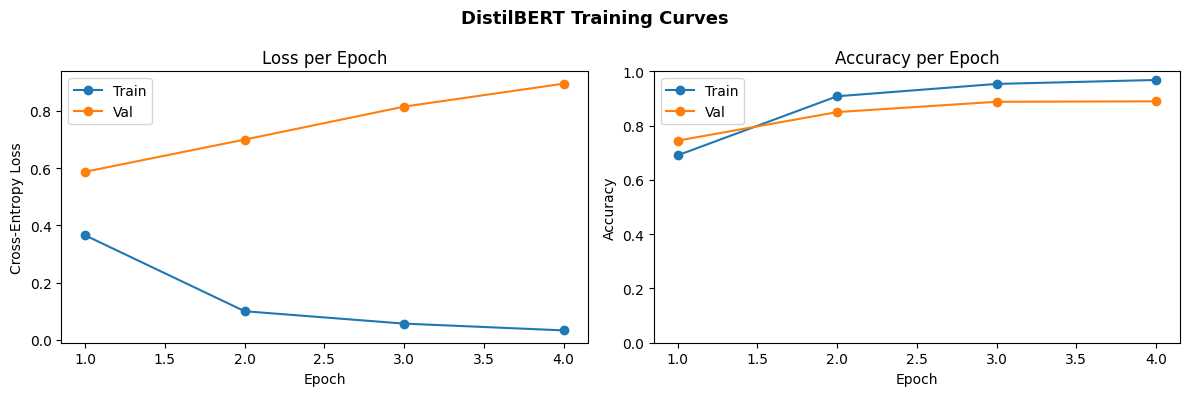


Test accuracy : 0.8946

Test classification report:
              precision    recall  f1-score   support

 Hate Speech       0.40      0.60      0.48       214
   Offensive       0.97      0.90      0.93      2879
     Neither       0.84      0.95      0.89       625

    accuracy                           0.89      3718
   macro avg       0.74      0.82      0.77      3718
weighted avg       0.91      0.89      0.90      3718



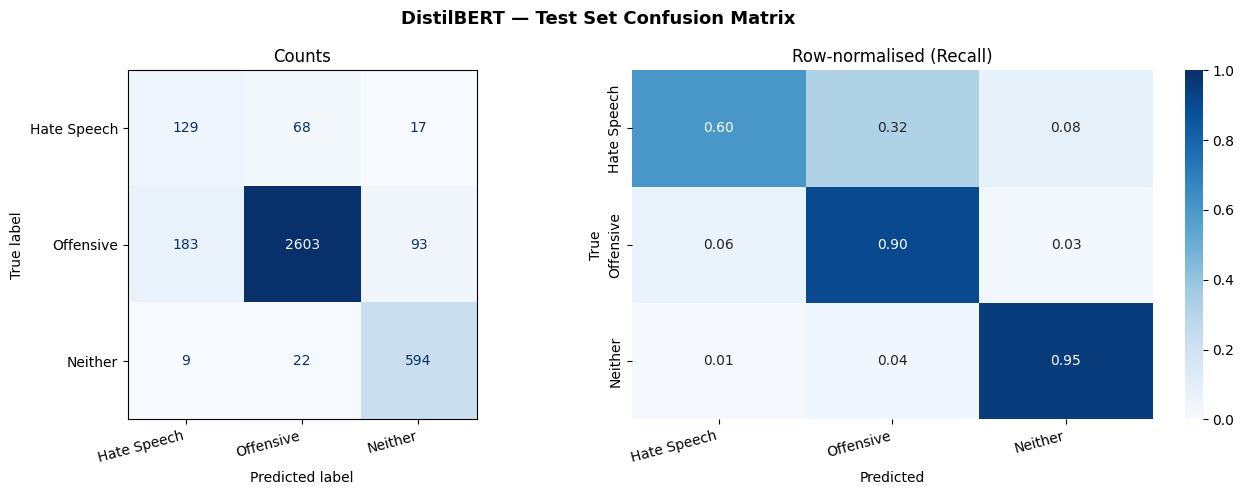

In [ ]:
# Configuration
NUM_LABELS  = 3
EPOCHS      = 4           # upper ceiling — early stopping will cut this short
LR          = 3e-5
BATCH_SIZE  = 32
MAX_LEN     = 128
DROPOUT     = 0.3         # applied to both attention and classifier head
PATIENCE    = 2           # epochs without val macro-F1 improvement before stopping

# To swap in HateBERT, change this one line:
# MODEL_NAME = "tomh/toxigen_hatebert"
MODEL_NAME  = "distilbert-base-uncased"

CLASS_NAMES = {0: "Hate Speech", 1: "Offensive", 2: "Neither"}
LABELS      = list(CLASS_NAMES.values())
PALETTE     = {"Hate Speech": "#d62728", "Offensive": "#ff7f0e", "Neither": "#2ca02c"}
CKPT_PATH   = "best_model.pt"   # checkpoint saved at the epoch with best val macro-F1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load preprocessed splits from Part 1
X_train = np.load("../data/npy_files/X_train.npy", allow_pickle=True)
X_val   = np.load("../data/npy_files/X_val.npy",   allow_pickle=True)
X_test  = np.load("../data/npy_files/X_test.npy",  allow_pickle=True)
y_train = np.load("../data/npy_files/y_train.npy", allow_pickle=True)
y_val   = np.load("../data/npy_files/y_val.npy",   allow_pickle=True)
y_test  = np.load("../data/npy_files/y_test.npy",  allow_pickle=True)

# Wraps tokenized tweets and integer labels into a PyTorch Dataset
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

tokenizer     = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
train_dataset = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# WeightedRandomSampler oversamples the minority hate speech class so each
# training batch contains a more balanced class distribution
class_counts   = np.bincount(y_train)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Load DistilBERT with higher dropout than the default 0.1 to reduce overfitting.
# attention_dropout applies inside each transformer block;
# seq_classif_dropout applies to the final classification head.
config = DistilBertConfig.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    attention_dropout=DROPOUT,
    seq_classif_dropout=DROPOUT
)
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)
model.to(device)

# CrossEntropyLoss with per-class inverse-frequency weights penalises
# misclassification of the rare hate speech class more heavily
loss_weights = torch.tensor(class_weights / class_weights.sum(), dtype=torch.float).to(device)
criterion    = nn.CrossEntropyLoss(weight=loss_weights * NUM_LABELS)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Linear warmup for the first 10% of steps, then linear decay to zero.
# Warmup prevents large destructive gradient updates at the start of fine-tuning.
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# Runs one full pass over the given DataLoader.
# Returns average loss and accuracy for that pass.
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attn_mask)
            loss    = criterion(outputs.logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * labels.size(0)
            preds       = outputs.logits.argmax(dim=-1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total


# Collects predictions and optionally raw softmax probabilities for a DataLoader.
# return_probs=True is used for the confidence coverage curve and calibration.
def get_predictions(loader, return_probs=False):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["labels"].to(device)
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
            probs     = torch.softmax(outputs.logits, dim=-1)
            preds     = probs.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    if return_probs:
        return np.array(all_labels), np.array(all_preds), np.array(all_probs)
    return np.array(all_labels), np.array(all_preds)


# Computes macro-F1 on the validation set.
# Used as the early stopping criterion instead of accuracy or loss,
# because macro-F1 is more sensitive to performance on the minority hate speech class.
def val_macro_f1():
    y_true, y_pred = get_predictions(val_loader)
    return f1_score(y_true, y_pred, average="macro")


# Training loop with early stopping on val macro-F1.
# The best model checkpoint is saved whenever val macro-F1 improves.
# Training stops if no improvement is seen for PATIENCE consecutive epochs.
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

best_f1       = 0.0
epochs_no_imp = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    vl_f1           = val_macro_f1()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"Val loss {vl_loss:.4f} acc {vl_acc:.4f} | "
          f"Val macro-F1 {vl_f1:.4f}")

    if vl_f1 > best_f1:
        best_f1 = vl_f1
        epochs_no_imp = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  Best macro-F1 {best_f1:.4f} — checkpoint saved.")
    else:
        epochs_no_imp += 1
        print(f"  No improvement ({epochs_no_imp}/{PATIENCE})")
        if epochs_no_imp >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val macro-F1: {best_f1:.4f}")
            break

# Reload the best checkpoint so evaluation reflects the best generalising epoch,
# not the final (potentially overfit) epoch
model.load_state_dict(torch.load(CKPT_PATH))
print(f"\nLoaded best checkpoint (val macro-F1 = {best_f1:.4f})")


# Temperature scaling calibrates the model's confidence scores so that
# a predicted probability of 0.85 actually corresponds to ~85% accuracy.
# Without calibration the model is overconfident due to overfitting, making
# raw softmax scores unreliable as routing thresholds in production.
# T is a single scalar learned by minimising NLL on the validation set.
# T > 1 means the model was overconfident; probabilities are softened.

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, loader):
        self.train()
        nll = nn.CrossEntropyLoss()
        opt = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)

        all_logits, all_labels = [], []
        model.eval()
        with torch.no_grad():
            for batch in loader:
                out = model(
                    input_ids=batch["input_ids"].to(device),
                    attention_mask=batch["attention_mask"].to(device)
                )
                all_logits.append(out.logits.cpu())
                all_labels.append(batch["labels"])

        logits_cat = torch.cat(all_logits)
        labels_cat = torch.cat(all_labels)

        def eval_step():
            opt.zero_grad()
            loss = nll(self.forward(logits_cat), labels_cat)
            loss.backward()
            return loss

        opt.step(eval_step)
        print(f"Calibration complete. Temperature T = {self.temperature.item():.4f}")
        return self

scaler = TemperatureScaler().fit(val_loader)

# Evaluate on the test set using the best checkpoint
y_true, y_pred, raw_probs = get_predictions(test_loader, return_probs=True)

# Apply temperature scaling to raw softmax probabilities
with torch.no_grad():
    logits_approx = torch.log(torch.tensor(raw_probs).clamp(min=1e-9))
    calib_probs   = torch.softmax(scaler(logits_approx), dim=-1).numpy()
max_calib_conf = calib_probs.max(axis=1)

print(f"\nTest accuracy : {accuracy_score(y_true, y_pred):.4f}")
print("\nTest classification report:")
print(classification_report(y_true, y_pred, target_names=LABELS))

report_dict = classification_report(y_true, y_pred, target_names=LABELS, output_dict=True)
pd.DataFrame(report_dict).T.to_csv("transformer_metrics.csv")

# Training curves — three subplots: loss, accuracy, and val macro-F1.
# The macro-F1 subplot includes a vertical line at the best epoch so the
# early stopping decision is visually clear.
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes    = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("DistilBERT Training Curves", fontsize=13, fontweight="bold")

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_range, history["val_loss"],   marker="o", label="Val")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train")
axes[1].plot(epochs_range, history["val_acc"],   marker="o", label="Val")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1); axes[1].legend()

axes[2].plot(epochs_range, history["val_f1"], marker="o", color="purple", label="Val macro-F1")
axes[2].axvline(x=np.argmax(history["val_f1"]) + 1, color="red", linestyle="--", label="Best epoch")
axes[2].set_title("Val Macro-F1 per Epoch")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro-F1")
axes[2].set_ylim(0, 1); axes[2].legend()

plt.tight_layout()
plt.savefig("../data/content/transformer_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Confusion matrices — raw counts (left) and row-normalised recall rates (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DistilBERT — Test Set Confusion Matrix", fontsize=13, fontweight="bold")

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Counts")
axes[0].set_xticklabels(LABELS, rotation=15, ha="right")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Row-normalised (Recall)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_xticklabels(LABELS, rotation=15, ha="right")

plt.tight_layout()
plt.savefig("../data/content/transformer_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

# Confidence coverage curve using calibrated probabilities.
# At each threshold, only posts where the model's top-class confidence exceeds
# that threshold are auto-decided. The curve shows the accuracy vs. coverage
# trade-off, which directly informs the routing thresholds in the production workflow.
thresholds = np.arange(0.5, 1.0, 0.02)
coverages, accuracies = [], []

for t in thresholds:
    mask = max_calib_conf >= t
    if mask.sum() == 0:
        break
    coverages.append(mask.mean())
    accuracies.append(accuracy_score(y_true[mask], y_pred[mask]))

plt.figure(figsize=(7, 4))
plt.plot(coverages, accuracies, marker="o")
plt.xlabel("Coverage (fraction of posts auto-decided)")
plt.ylabel("Accuracy on auto-decided posts")
plt.title("Accuracy vs. Coverage (calibrated confidence)")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/content/confidence_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

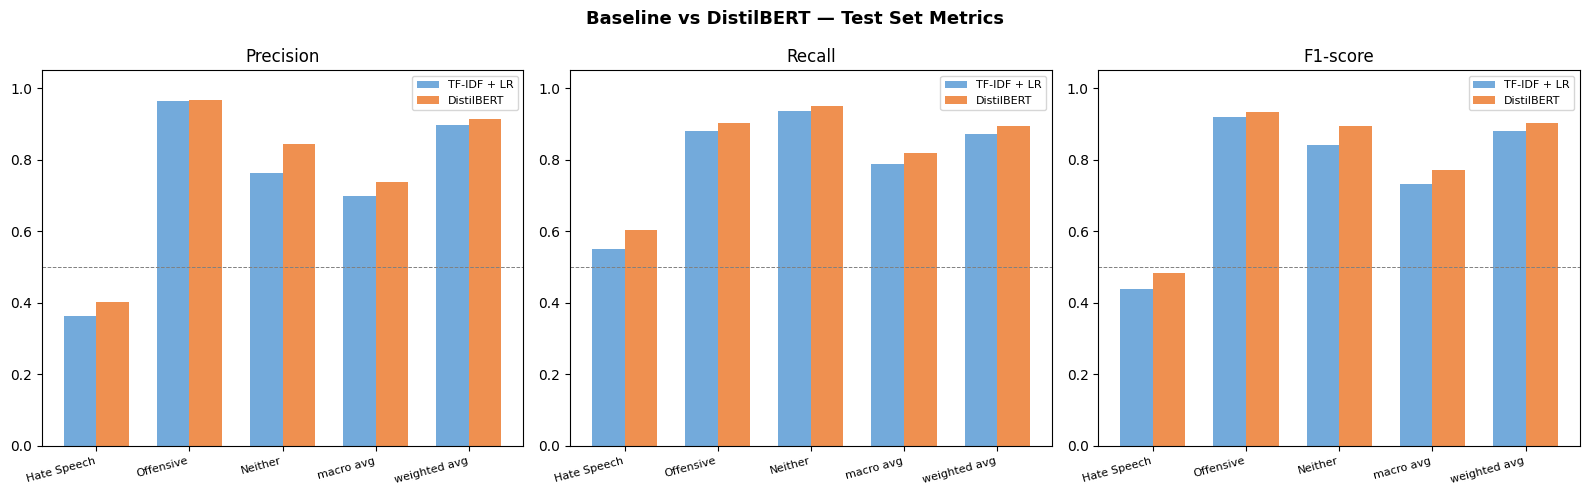

Metric delta (DistilBERT − Baseline):
              precision  recall  f1-score
Hate Speech      0.0377  0.0514    0.0436
Offensive        0.0020  0.0236    0.0137
Neither          0.0800  0.0144    0.0528
macro avg        0.0399  0.0298    0.0367
weighted avg     0.0171  0.0237    0.0220

Per-class F1 — Baseline:
Hate Speech    0.4387
Offensive      0.9206
Neither        0.8411
Name: f1-score, dtype: float64

Per-class F1 — DistilBERT:
Hate Speech    0.4822
Offensive      0.9343
Neither        0.8939
Name: f1-score, dtype: float64

Misclassified examples (transformer):
                                                                                                                                         tweet  true_label  pred_label  confidence        failure_category
                                                                                       RT [USER]: &8220;[USER]: Fat bitch. What's her @? [URL]   Offensive Hate Speech       0.997       Context-Dependent
                 

/var/folders/9j/j3l8k_gn4bs6ck3ld3yw7fyw0000gn/T/ipykernel_54124/2617267752.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 4), random_state=SEED)))


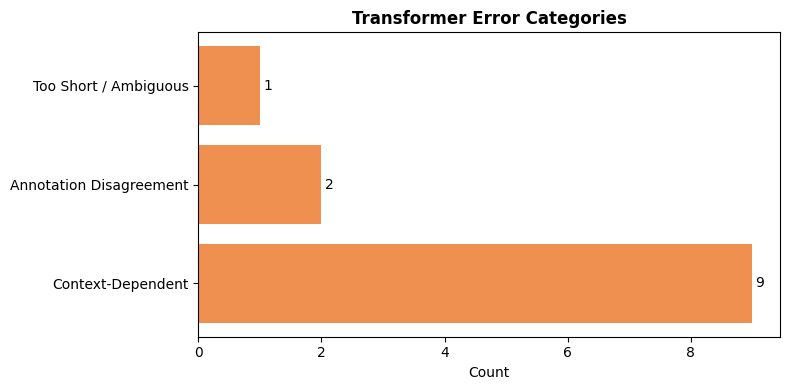

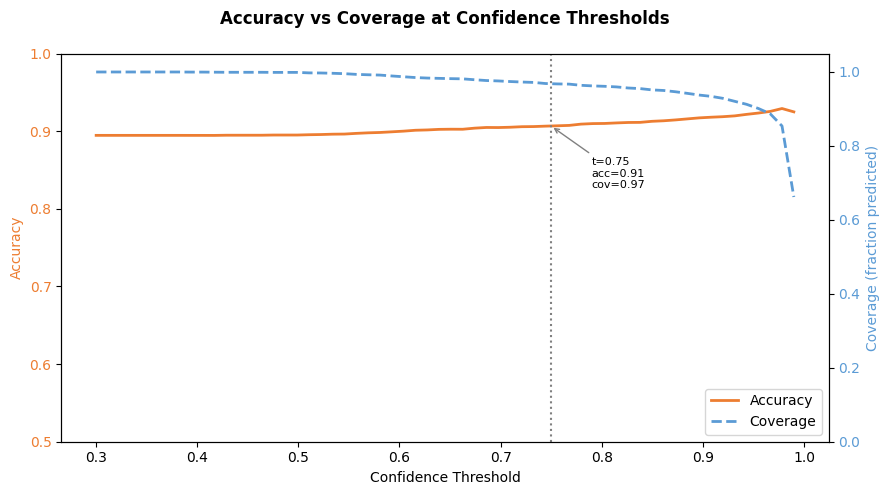

In [ ]:
# Comparative analysis & error analysis

# Load baseline metrics (from Part 2)
baseline_metrics = pd.read_csv("../data/content/baseline_metrics.csv", index_col=0)
transformer_metrics = pd.read_csv("../data/content/transformer_metrics.csv", index_col=0)

# Obtain prediction probabilities for error analysis
import torch.nn.functional as F

model.eval()
all_probs, all_preds, all_true = [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        labels    = batch["labels"]
        logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
        probs     = F.softmax(logits, dim=-1).cpu()
        all_probs.append(probs)
        all_preds.extend(probs.argmax(dim=-1).numpy())
        all_true.extend(labels.numpy())

all_probs = torch.cat(all_probs, dim=0).numpy()
all_preds = np.array(all_preds)
all_true  = np.array(all_true)
confidence = all_probs.max(axis=1)

# 1) Side-by-side model comparison
metrics_rows = ["Hate Speech", "Offensive", "Neither", "macro avg", "weighted avg"]
compare_cols = ["precision", "recall", "f1-score"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Baseline vs DistilBERT — Test Set Metrics", fontsize=13, fontweight="bold")

for ax, metric in zip(axes, compare_cols):
    base_vals  = baseline_metrics.loc[metrics_rows, metric].values.astype(float)
    trans_vals = transformer_metrics.loc[metrics_rows, metric].values.astype(float)
    x = np.arange(len(metrics_rows))
    w = 0.35
    ax.bar(x - w/2, base_vals,  w, label="TF-IDF + LR",  color="#5b9bd5", alpha=0.85)
    ax.bar(x + w/2, trans_vals, w, label="DistilBERT",    color="#ed7d31", alpha=0.85)
    ax.set_title(metric.capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_rows, rotation=15, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", linewidth=0.7, linestyle="--")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/content/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Metric delta (DistilBERT − Baseline):")
delta = transformer_metrics.loc[metrics_rows, compare_cols].astype(float) - \
        baseline_metrics.loc[metrics_rows, compare_cols].astype(float)
print(delta.round(4).to_string())

# 2) Per-class trouble spots
print("\nPer-class F1 — Baseline:")
print(baseline_metrics.loc[LABELS, "f1-score"].round(4))
print("\nPer-class F1 — DistilBERT:")
print(transformer_metrics.loc[LABELS, "f1-score"].round(4))

# 3) Error analysis for transformer
errors_mask = all_preds != all_true
error_texts  = X_test[errors_mask]
error_true   = all_true[errors_mask]
error_pred   = all_preds[errors_mask]
error_conf   = confidence[errors_mask]

np.random.seed(SEED)
error_df = pd.DataFrame({
    "tweet":      error_texts,
    "true_label": [CLASS_NAMES[c] for c in error_true],
    "pred_label": [CLASS_NAMES[c] for c in error_pred],
    "confidence": error_conf.round(3)
})

sampled = (error_df.groupby("true_label", group_keys=False)
                   .apply(lambda g: g.sample(min(len(g), 4), random_state=SEED)))
sampled = sampled.sample(frac=1, random_state=SEED).head(12).reset_index(drop=True)

# Tag failure categories

def categorise_error(row):
    text = row["tweet"].lower()
    if any(w in text for w in ["lol", "haha", "jk", "/s", "irony"]):
        return "Sarcasm / Irony"
    if any(w in text for w in ["[user]", "[url]"]):
        return "Context-Dependent"
    if len(text.split()) < 6:
        return "Too Short / Ambiguous"
    if row["true_label"] == "Hate Speech" and row["pred_label"] == "Offensive":
        return "Hate↔Offensive Confusion"
    if row["confidence"] < 0.60:
        return "Annotation Disagreement"
    return "Slang / Informal Language"

sampled["failure_category"] = sampled.apply(categorise_error, axis=1)

print("\nMisclassified examples (transformer):")
pd.set_option("display.max_colwidth", 80)
print(sampled[["tweet", "true_label", "pred_label", "confidence", "failure_category"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
cat_counts = sampled["failure_category"].value_counts()
ax.barh(cat_counts.index, cat_counts.values, color="#ed7d31", alpha=0.85)
ax.set_title("Transformer Error Categories", fontweight="bold")
ax.set_xlabel("Count")
for i, v in enumerate(cat_counts.values):
    ax.text(v + 0.05, i, str(v), va="center")
plt.tight_layout()
plt.savefig("../data/content/error_categories.png", dpi=150, bbox_inches="tight")
plt.show()

# 4) Confidence threshold analysis
thresholds = np.linspace(0.3, 0.99, 60)
coverages, accuracies = [], []

for t in thresholds:
    mask = confidence >= t
    if mask.sum() == 0:
        break
    coverages.append(mask.mean())
    accuracies.append(accuracy_score(all_true[mask], all_preds[mask]))

fig, ax1 = plt.subplots(figsize=(9, 5))
fig.suptitle("Accuracy vs Coverage at Confidence Thresholds", fontweight="bold")

color_acc, color_cov = "#ed7d31", "#5b9bd5"
ax1.plot(thresholds[:len(accuracies)], accuracies, color=color_acc,
         linewidth=2, label="Accuracy")
ax1.set_xlabel("Confidence Threshold")
ax1.set_ylabel("Accuracy", color=color_acc)
ax1.tick_params(axis="y", labelcolor=color_acc)
ax1.set_ylim(0.5, 1.0)

ax2 = ax1.twinx()
ax2.plot(thresholds[:len(coverages)], coverages, color=color_cov,
         linewidth=2, linestyle="--", label="Coverage")
ax2.set_ylabel("Coverage (fraction predicted)", color=color_cov)
ax2.tick_params(axis="y", labelcolor=color_cov)
ax2.set_ylim(0, 1.05)

op_thresh = 0.75
op_idx    = np.argmin(np.abs(thresholds[:len(accuracies)] - op_thresh))
ax1.axvline(op_thresh, color="grey", linestyle=":", linewidth=1.5)
ax1.annotate(
    f"t={op_thresh}\nacc={accuracies[op_idx]:.2f}\ncov={coverages[op_idx]:.2f}",
    xy=(op_thresh, accuracies[op_idx]),
    xytext=(op_thresh + 0.04, accuracies[op_idx] - 0.08),
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="grey"),
)

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc="lower right")

plt.tight_layout()
plt.savefig("../data/content/confidence_coverage.png", dpi=150, bbox_inches="tight")
plt.show()


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Zone distribution on test set:
  auto_remove      2614  (70.3%)
  human_review      464  (12.5%)
  auto_approve      640  (17.2%)

Auto-remove precision (harmful): 0.996
Hate speech slipping into auto-approve: 12 (1.88%)


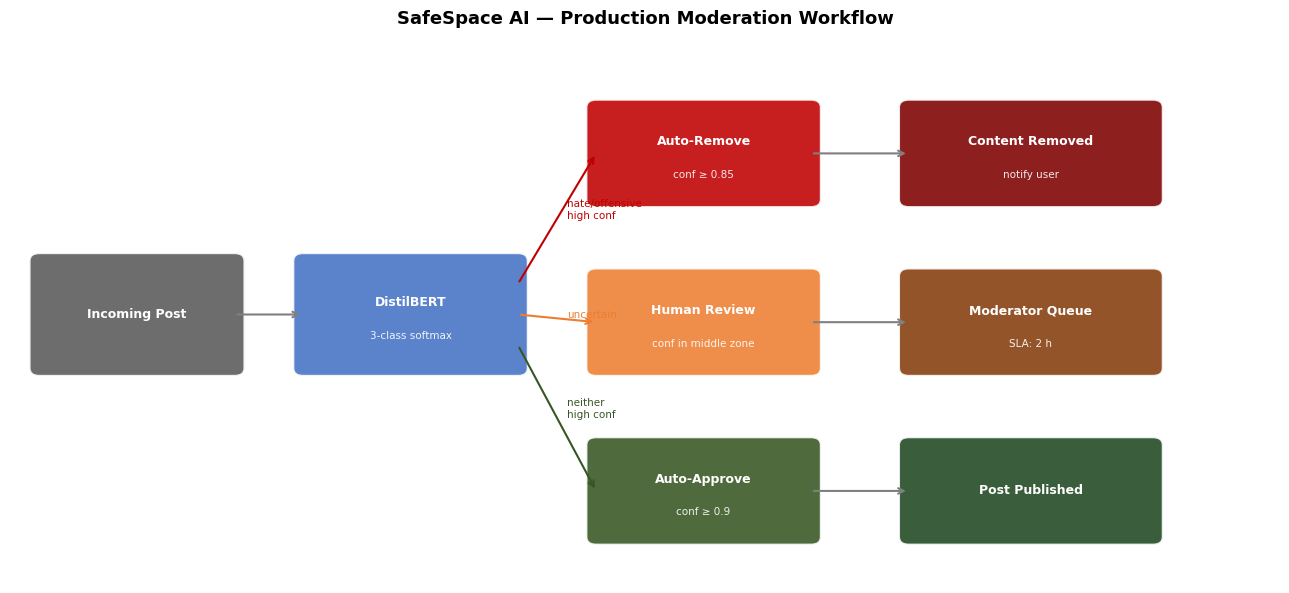


Error Cost Analysis
-------------------
False Negative (miss hate speech → auto-approve):
  - Legal risk: EU DSA / US FOSTA-SESTA impose platform liability
  - Reputational damage if hate content goes viral
  - Estimated cost: HIGH

False Positive (flag clean post → auto-remove):
  - User frustration, possible appeals workload
  - Risk of chilling legitimate speech, user churn
  - Estimated cost: MEDIUM

Decision: thresholds are asymmetric.
  - Auto-remove bar (0.85) is LOWER than auto-approve bar (0.90)
    so we err on the side of caution for harmful content.
  - Any post with hate_prob >= 0.30 is escalated to human review
    even if another class has the plurality, providing a safety net.



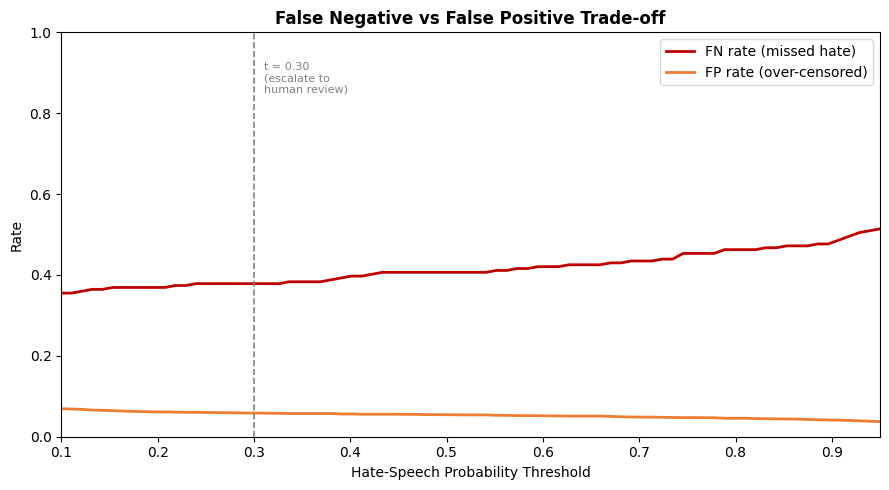

Scalability at 100,000 posts/day:
  Auto-removed   :  70,306  (70.3%)
  Human review   :  12,479  (12.5%)
  Auto-approved  :  17,213  (17.2%)
  Moderators needed (400 posts/mod/day): 3.9


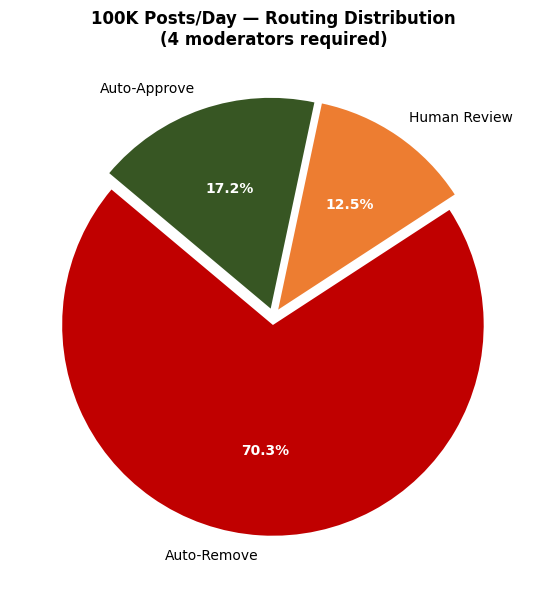


Limitations (v1)
----------------
1. Sarcasm & irony       — model takes language literally; "great job being racist"
                           may be flagged as hate speech.
2. Multilingual content  — DistilBERT-base is English-only; non-English hate speech
                           passes through undetected.
3. Slang drift           — internet slang evolves rapidly; the 2017 training corpus
                           will miss newer coded language and dog-whistles.
4. Context blindness     — a single tweet is classified in isolation; reply threads,
                           images, and user history are ignored.
5. Annotation noise      — the dataset has known disagreement between annotators,
                           especially at the hate/offensive boundary (~7% of labels).

v2 Recommendations
------------------
1. Upgrade model         — fine-tune HateBERT or a Twitter-pretrained model
                           (e.g., twitter-roberta-base) for better domain fit.
2. Thread con

In [ ]:
# COMP 9130 — Mini Project 9
# SafeSpace AI — Part 5: Production Workflow Design

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, confusion_matrix

SEED        = 42
NUM_LABELS  = 3
BATCH_SIZE  = 32
MAX_LEN     = 128
CLASS_NAMES = {0: "Hate Speech", 1: "Offensive", 2: "Neither"}
LABELS      = list(CLASS_NAMES.values())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load test split
DATA_DIR = "../data/npy_files"
X_test = np.load(f"{DATA_DIR}/X_test.npy", allow_pickle=True)
y_test = np.load(f"{DATA_DIR}/y_test.npy", allow_pickle=True)

# Reload model and collect softmax probabilities
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

test_dataset = TweetDataset(X_test, y_test, tokenizer, MAX_LEN)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=NUM_LABELS
)
model.load_state_dict(torch.load("distilbert_safespace.pt", map_location=device))
model.to(device)
model.eval()

all_probs, all_preds, all_true = [], [], []
with torch.no_grad():
    for batch in test_loader:
        logits = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        ).logits
        probs = F.softmax(logits, dim=-1).cpu()
        all_probs.append(probs)
        all_preds.extend(probs.argmax(dim=-1).numpy())
        all_true.extend(batch["labels"].numpy())

all_probs  = torch.cat(all_probs).numpy()
all_preds  = np.array(all_preds)
all_true   = np.array(all_true)
confidence = all_probs.max(axis=1)
hate_prob  = all_probs[:, 0]   # class 0 = hate speech

# 1. Three-zone workflow 
# Zones are defined on the predicted-class confidence score.
# We use a stricter lower bound for hate speech (safety-critical).

T_REMOVE  = 0.85   # auto-remove:  high confidence harmful content
T_APPROVE = 0.90   # auto-approve: high confidence clean content
# anything between → human review queue

def assign_zone(prob_row):
    pred   = prob_row.argmax()
    conf   = prob_row.max()
    h_prob = prob_row[0]

    # Escalate to human if hate-speech probability is non-trivial even
    # when another class wins (hedge against borderline cases)
    if h_prob >= 0.30:
        return "human_review"
    if pred in (0, 1) and conf >= T_REMOVE:
        return "auto_remove"
    if pred == 2 and conf >= T_APPROVE:
        return "auto_approve"
    return "human_review"

zones = np.array([assign_zone(p) for p in all_probs])

zone_counts = {z: (zones == z).sum() for z in
               ["auto_remove", "human_review", "auto_approve"]}
total = len(zones)

print("Zone distribution on test set:")
for z, n in zone_counts.items():
    print(f"  {z:<15} {n:>5}  ({n/total*100:.1f}%)")

# Precision of auto-remove zone (what fraction are truly harmful)
remove_mask = zones == "auto_remove"
if remove_mask.sum():
    remove_precision = (all_true[remove_mask] < 2).mean()
    print(f"\nAuto-remove precision (harmful): {remove_precision:.3f}")

# False-negative rate for hate speech in auto-approve zone
approve_mask = zones == "auto_approve"
if approve_mask.sum():
    fn_hate = ((all_true[approve_mask] == 0).sum())
    print(f"Hate speech slipping into auto-approve: {fn_hate} "
          f"({fn_hate/approve_mask.sum()*100:.2f}%)")

# 2. Workflow diagram 
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis("off")
fig.suptitle("SafeSpace AI — Production Moderation Workflow", fontsize=13, fontweight="bold")

# Helper: rounded rectangle
def draw_box(ax, x, y, w, h, label, sublabel="", color="#4472c4", fontsize=9):
    box = mpatches.FancyBboxPatch((x, y), w, h,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor="white",
                                   linewidth=1.5, alpha=0.88)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0),
            label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color="white")
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.28, sublabel,
                ha="center", va="center", fontsize=7.5, color="white", alpha=0.9)

# Helper: arrow
def arrow(ax, x1, y1, x2, y2, label="", color="grey"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.1, my, label, fontsize=7.5, color=color)

# Boxes
draw_box(ax, 0.3, 2.8, 2.0, 1.4, "Incoming Post",    color="#595959")
draw_box(ax, 3.0, 2.8, 2.2, 1.4, "DistilBERT",       "3-class softmax", color="#4472c4")
draw_box(ax, 6.0, 5.0, 2.2, 1.2, "Auto-Remove",      f"conf ≥ {T_REMOVE}", color="#c00000")
draw_box(ax, 6.0, 2.8, 2.2, 1.2, "Human Review",     "conf in middle zone", color="#ed7d31")
draw_box(ax, 6.0, 0.6, 2.2, 1.2, "Auto-Approve",     f"conf ≥ {T_APPROVE}", color="#375623")
draw_box(ax, 9.2, 5.0, 2.5, 1.2, "Content Removed",  "notify user", color="#7f0000")
draw_box(ax, 9.2, 2.8, 2.5, 1.2, "Moderator Queue",  "SLA: 2 h", color="#843c0c")
draw_box(ax, 9.2, 0.6, 2.5, 1.2, "Post Published",   color="#1e4620")

# Arrows
arrow(ax, 2.3, 3.5, 3.0, 3.5)
arrow(ax, 5.2, 3.9, 6.0, 5.6,  "hate/offensive\nhigh conf", "#c00000")
arrow(ax, 5.2, 3.5, 6.0, 3.4,  "uncertain", "#ed7d31")
arrow(ax, 5.2, 3.1, 6.0, 1.2,  "neither\nhigh conf", "#375623")
arrow(ax, 8.2, 5.6, 9.2, 5.6)
arrow(ax, 8.2, 3.4, 9.2, 3.4)
arrow(ax, 8.2, 1.2, 9.2, 1.2)

plt.tight_layout()
plt.savefig("workflow_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Error cost analysis 
# Cost matrix: rows = true, cols = predicted
# Asymmetric: missing hate speech (FN) is more costly than over-censoring (FP)

print("""
Error Cost Analysis
-------------------
False Negative (miss hate speech → auto-approve):
  - Legal risk: EU DSA / US FOSTA-SESTA impose platform liability
  - Reputational damage if hate content goes viral
  - Estimated cost: HIGH

False Positive (flag clean post → auto-remove):
  - User frustration, possible appeals workload
  - Risk of chilling legitimate speech, user churn
  - Estimated cost: MEDIUM

Decision: thresholds are asymmetric.
  - Auto-remove bar (0.85) is LOWER than auto-approve bar (0.90)
    so we err on the side of caution for harmful content.
  - Any post with hate_prob >= 0.30 is escalated to human review
    even if another class has the plurality, providing a safety net.
""")

# Visualise cost trade-off at different hate-speech detection thresholds
thresholds = np.linspace(0.1, 0.95, 80)
fn_rates, fp_rates, human_rates = [], [], []

for t in thresholds:
    # flag = predict hate if hate_prob >= t
    flagged   = hate_prob >= t
    fn = ((all_true == 0) & ~flagged).sum() / (all_true == 0).sum()   # missed hate
    fp = ((all_true != 0) &  flagged).sum() / (all_true != 0).sum()   # over-flagged
    hr = (~flagged).mean()   # not auto-flagged (goes to next decision point)
    fn_rates.append(fn); fp_rates.append(fp); human_rates.append(hr)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, fn_rates, color="#c00000", linewidth=2, label="FN rate (missed hate)")
ax.plot(thresholds, fp_rates, color="#ed7d31", linewidth=2, label="FP rate (over-censored)")
ax.axvline(0.30, color="grey", linestyle="--", linewidth=1.2)
ax.text(0.31, 0.85, "t = 0.30\n(escalate to\nhuman review)", fontsize=8, color="grey")
ax.set_xlabel("Hate-Speech Probability Threshold")
ax.set_ylabel("Rate")
ax.set_title("False Negative vs False Positive Trade-off", fontweight="bold")
ax.legend()
ax.set_xlim(0.1, 0.95)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("cost_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Scalability at 100 K posts/day 
DAILY_POSTS = 100_000

review_pct  = zone_counts["human_review"] / total
remove_pct  = zone_counts["auto_remove"]  / total
approve_pct = zone_counts["auto_approve"] / total

daily_review  = int(DAILY_POSTS * review_pct)
daily_remove  = int(DAILY_POSTS * remove_pct)
daily_approve = int(DAILY_POSTS * approve_pct)

# Moderator capacity: 1 moderator reviews ~400 posts/hour, 8-hour shift
POSTS_PER_MOD_DAY = 400 * 8
mods_needed = daily_review / POSTS_PER_MOD_DAY

print("Scalability at 100,000 posts/day:")
print(f"  Auto-removed   : {daily_remove:>7,}  ({remove_pct*100:.1f}%)")
print(f"  Human review   : {daily_review:>7,}  ({review_pct*100:.1f}%)")
print(f"  Auto-approved  : {daily_approve:>7,}  ({approve_pct*100:.1f}%)")
print(f"  Moderators needed (400 posts/mod/day): {mods_needed:.1f}")

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
sizes  = [remove_pct, review_pct, approve_pct]
clrs   = ["#c00000", "#ed7d31", "#375623"]
explode = (0.04, 0.04, 0.04)
wedges, texts, autotexts = ax.pie(
    sizes, labels=["Auto-Remove", "Human Review", "Auto-Approve"],
    colors=clrs, explode=explode, autopct="%1.1f%%",
    startangle=140, textprops={"fontsize": 10}
)
for at in autotexts:
    at.set_color("white"); at.set_fontweight("bold")
ax.set_title(f"100K Posts/Day — Routing Distribution\n"
             f"({mods_needed:.0f} moderators required)", fontweight="bold")
plt.tight_layout()
plt.savefig("scalability_pie.png", dpi=150, bbox_inches="tight")
plt.show()

#  5. Limitations & v2 recommendations 
print("""
Limitations (v1)
----------------
1. Sarcasm & irony       — model takes language literally; "great job being racist"
                           may be flagged as hate speech.
2. Multilingual content  — DistilBERT-base is English-only; non-English hate speech
                           passes through undetected.
3. Slang drift           — internet slang evolves rapidly; the 2017 training corpus
                           will miss newer coded language and dog-whistles.
4. Context blindness     — a single tweet is classified in isolation; reply threads,
                           images, and user history are ignored.
5. Annotation noise      — the dataset has known disagreement between annotators,
                           especially at the hate/offensive boundary (~7% of labels).

v2 Recommendations
------------------
1. Upgrade model         — fine-tune HateBERT or a Twitter-pretrained model
                           (e.g., twitter-roberta-base) for better domain fit.
2. Thread context        — pass the parent tweet + reply together as a single input.
3. Active learning loop  — route high-uncertainty posts to annotators; retrain monthly
                           to capture slang drift.
4. Multilingual support  — add mBERT or XLM-R for non-English detection.
5. Confidence calibration — apply temperature scaling post-training so softmax
                            probabilities are better calibrated for threshold decisions.
6. Audit & fairness      — measure false-positive rates disaggregated by dialect
                           (e.g., AAVE) to reduce disparate impact on marginalised groups.
""")